In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import polatory as p
import polatory.three as p3

def variog(m: p3.Model, diff: np.ndarray) -> float:
    v = m.nugget
    for rbf in m.rbfs:
        v += rbf.evaluate(np.zeros(3)) - rbf.evaluate(diff)
    return v

In [10]:
data = np.loadtxt("data/grade.csv", delimiter=",")
points, values = data[:, :3], data[:, 3]

In [11]:

directions = np.array(
    [
        [0.0, 0.0, 1.0],
        [0.10607892, 0.32647735, 0.9392336],
        [-0.27771825, 0.20177411, 0.9392336],
        [-0.18759248, 0.57735026, 0.79465449],
        [-0.55543649, 0.40354821, 0.72707576],
        [-0.44935754, 0.73002559, 0.51491791],
        [-0.72360682, 0.52573109, 0.44721359],
        [0.21215785, 0.6529547, 0.72707576],
        [-0.065560378, 0.85472882, 0.51491791],
        [0.2763932, 0.85065079, 0.44721359],
        [-0.27771825, -0.20177411, 0.9392336],
        [-0.60706198, 0.0, 0.79465449],
        [-0.55543649, -0.40354821, 0.72707576],
        [-0.83315468, -0.20177411, 0.51491791],
        [-0.72360682, -0.52573109, 0.44721359],
        [-0.83315468, 0.20177411, 0.51491791],
        [0.10607892, -0.32647735, 0.9392336],
        [-0.18759248, -0.57735026, 0.79465449],
        [0.21215785, -0.6529547, 0.72707576],
        [-0.065560378, -0.85472882, 0.51491791],
        [0.2763932, -0.85065079, 0.44721359],
        [-0.44935754, -0.73002559, 0.51491791],
        [0.34327862, 0.0, 0.9392336],
        [0.49112347, -0.3568221, 0.79465449],
        [0.68655723, 0.0, 0.72707576],
        [0.79263616, -0.32647735, 0.51491791],
        [0.89442718, 0.0, 0.44721359],
        [0.55543649, -0.6529547, 0.51491791],
        [0.49112347, 0.3568221, 0.79465449],
        [0.55543649, 0.6529547, 0.51491791],
        [0.79263616, 0.32647735, 0.51491791],
        [0.10607892, 0.97943211, 0.17163931],
        [-0.30353099, 0.93417233, 0.18759248],
        [-0.66151541, 0.73002559, 0.17163931],
        [-0.89871508, 0.40354821, 0.17163931],
        [-0.98224694, 0.0, 0.18759248],
        [-0.89871508, -0.40354821, 0.17163931],
        [-0.66151541, -0.73002559, 0.17163931],
        [-0.30353099, -0.93417233, 0.18759248],
        [0.10607892, -0.97943211, 0.17163931],
        [0.48987609, -0.85472882, 0.17163931],
        [0.79465449, -0.57735026, 0.18759248],
        [0.96427548, -0.20177411, 0.17163931],
        [0.96427548, 0.20177411, 0.17163931],
        [0.79465449, 0.57735026, 0.18759248],
        [0.48987609, 0.85472882, 0.17163931],
    ]
)

variogs = p3.VariogramCalculator(points, values, bin_width=5.0, num_bins=40,
                                 angle_tolerance=np.degrees(22.5), directions=directions).variograms

In [12]:
cov1 = p3.CovSpheroidal9([0.3, 50.0])
cov2 = p3.CovSpheroidal9([0.3, 100.0])
m = p3.Model([cov1, cov2], poly_degree=0)

best_fit = None
best_cost = float("inf")
for _ in range(30):
    weight = p.WeightFunction(exp_num_pairs=1.0, exp_distance=-2.0)
    fit = p.VarioFitting(variogs, m, weight)
    if fit.final_cost < best_cost:
        best_fit = fit
        best_cost = fit.final_cost

m = best_fit.model

Ceres Solver Report: Iterations: 40, Initial cost: 8.089821e-03, Final cost: 1.797893e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 40, Initial cost: 8.089821e-03, Final cost: 1.797877e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 33, Initial cost: 8.089821e-03, Final cost: 1.799889e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 39, Initial cost: 8.089821e-03, Final cost: 1.797896e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 41, Initial cost: 8.089821e-03, Final cost: 1.797936e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 54, Initial cost: 8.089821e-03, Final cost: 1.944048e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 42, Initial cost: 8.089821e-03, Final cost: 2.627774e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 36, Initial cost: 8.089821e-03, Final cost: 1.798038e-03, Termination: CONVERGENCE
Ceres Solver Report: Iterations: 24, Initial cost: 8.089821e-03, Final c

In [13]:
for rbf in m.rbfs:
    print(rbf.parameters)
    print(rbf.anisotropy)
print(1.0 / best_fit.scale(0))
print(1.0 / best_fit.scale(1))

[0.4244494345417866, 35.22829568318267]
[[ 0.61705007 -0.09760945  0.38329414]
 [-0.12571091 -0.99080906 -0.04994181]
 [ 2.11307463 -0.09541019 -3.42605236]]
[0.2230325355611537, 119.15180562025256]
[[ 0.63373858 -0.10024936  0.39366057]
 [-0.12571091 -0.99080906 -0.04994181]
 [ 0.52480292 -0.02369606 -0.85089388]]
[1.36437865 1.         0.24835986]
[1.32844988 1.         1.        ]


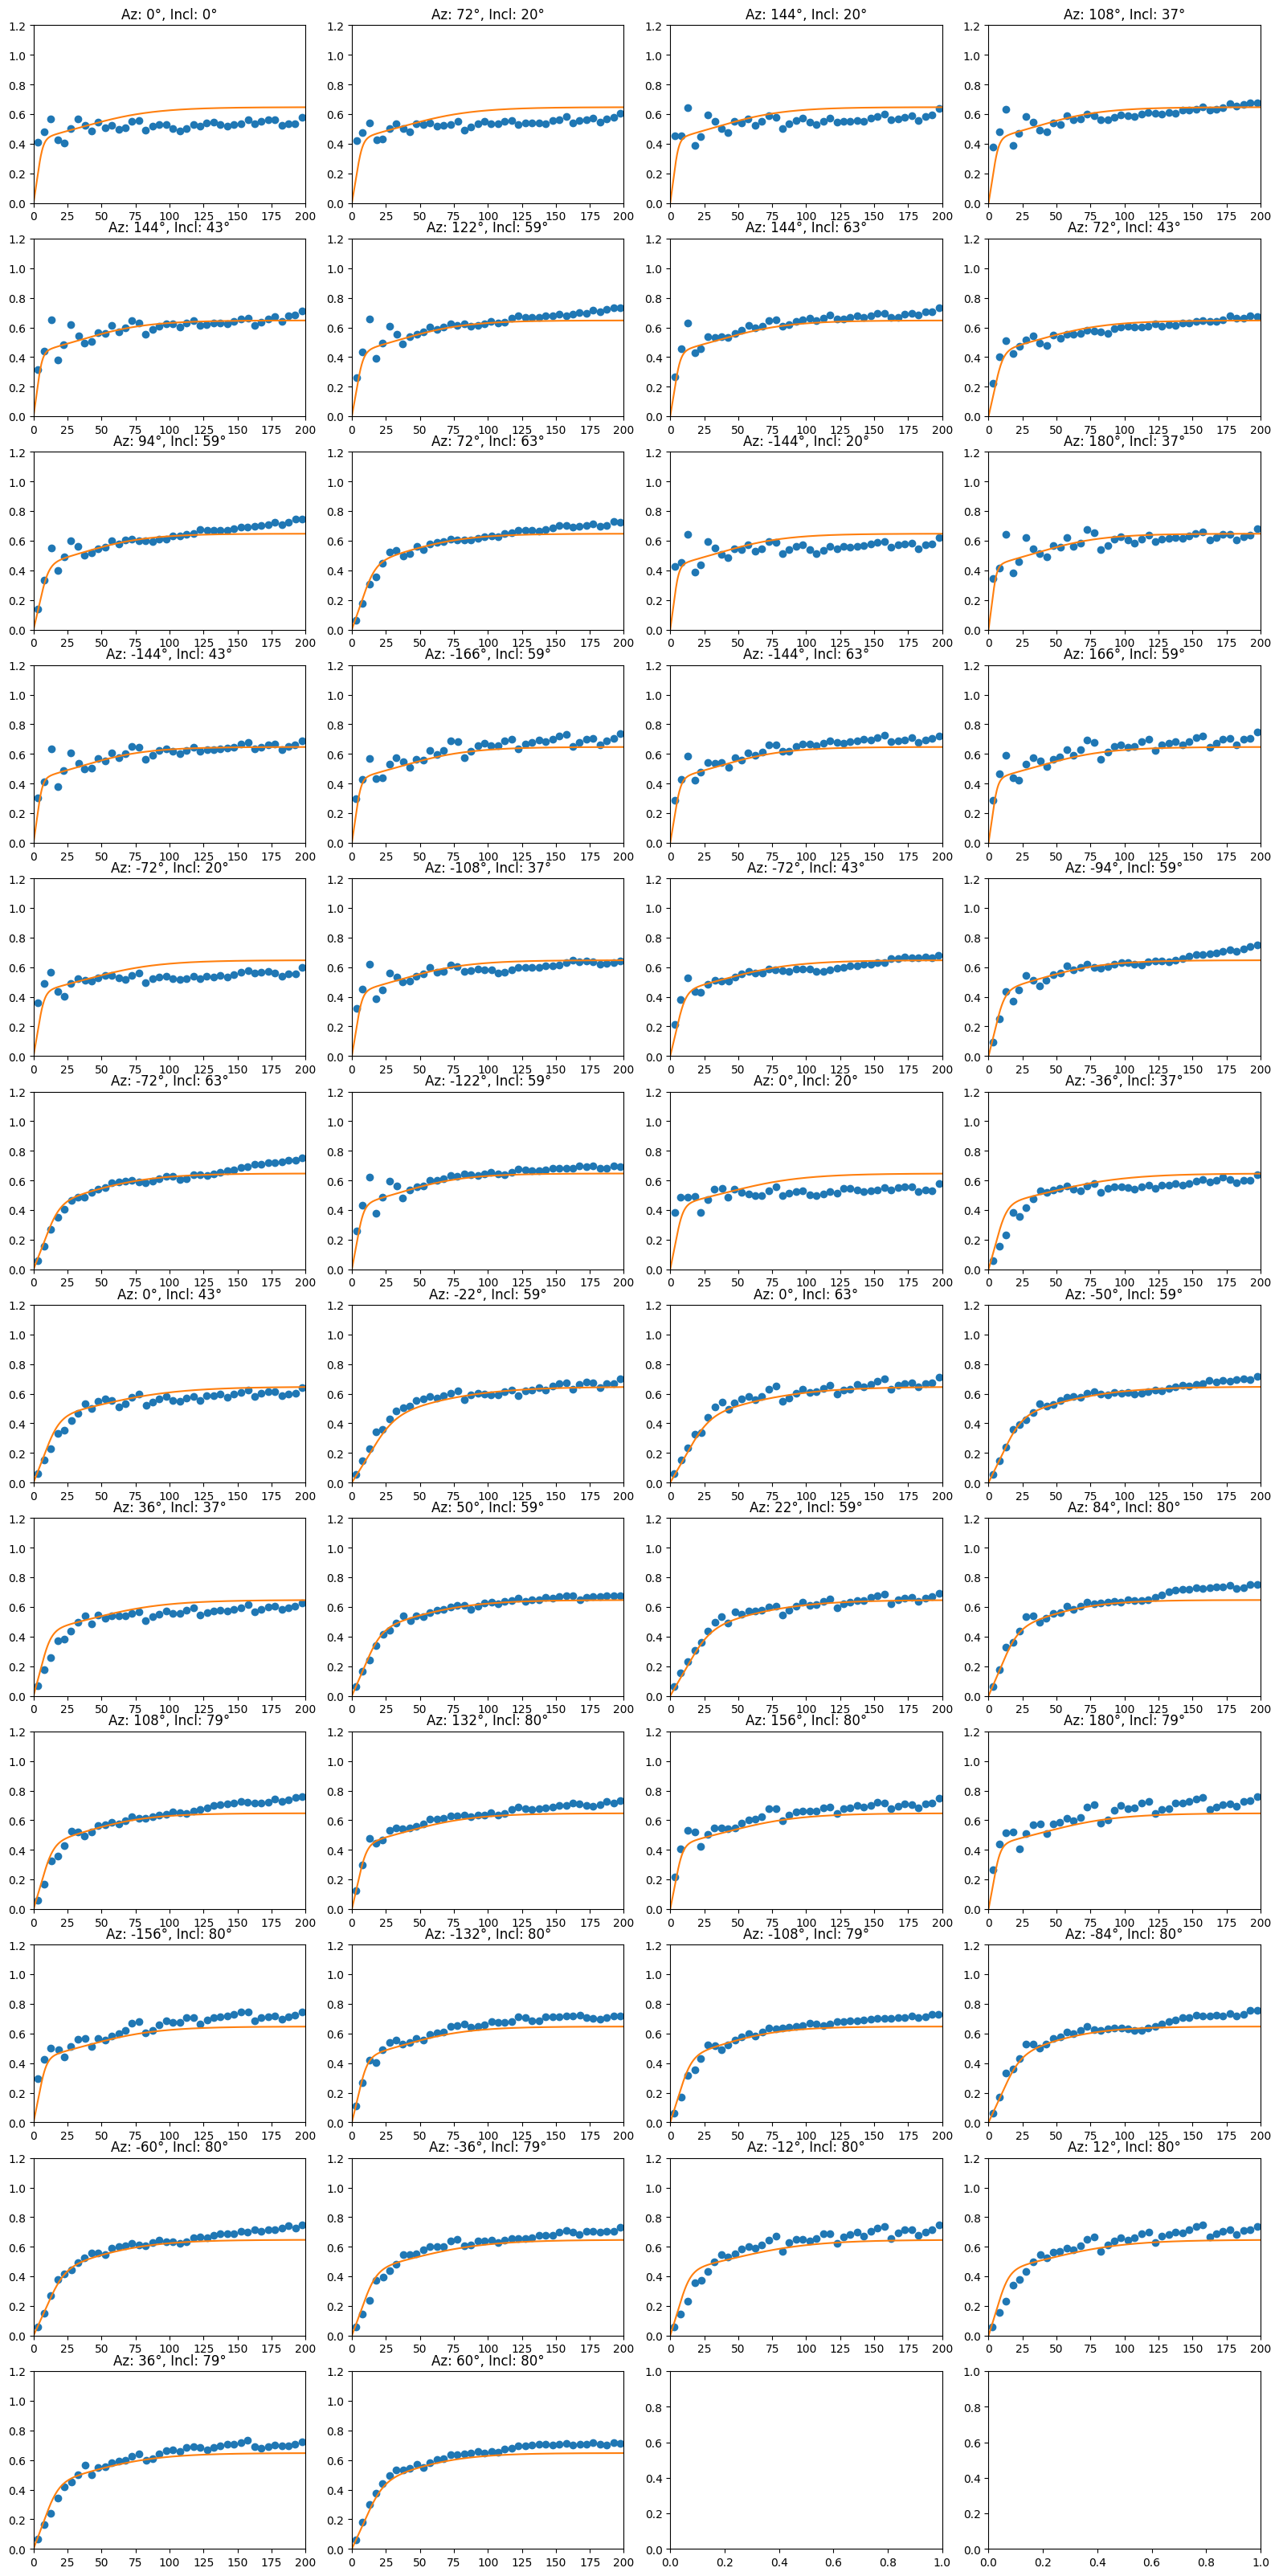

In [14]:

fig, ax = plt.subplots(nrows=12, ncols=4, figsize=(16, 32))
fig.tight_layout()
for i in range(12):
    for j in range(4):
        if 4 * i + j >= len(variogs):
            break
        v = variogs[4 * i + j]
        dir = v.direction
        az = np.degrees(np.arctan2(dir[1], dir[0]))
        incl = np.degrees(np.arccos(dir[2]))
        xs = np.linspace(0.0, 200.0, 1000)
        ys = np.array([variog(m, x * dir) for x in xs])
        ax[i, j].plot(v.bin_distance, v.bin_gamma, "o")
        ax[i, j].plot(xs, ys, "-")
        ax[i, j].set_title(f"Az: {az:.0f}°, Incl: {incl:.0f}°")
        ax[i, j].set_xlim(0.0, 200.0)
        ax[i, j].set_ylim(0.0, 1.2)
        ax[i, j].margins(0.0)

In [15]:
inter = p3.Interpolant(m)
inter.fit(points, values, absolute_tolerance=1e-3)

   level       n_domains        n_points
       1             128           61880
       0               1            1024
iter         rel_res
   0    1.000000e+00
   1    8.427035e-01
   2    3.649867e-01
   3    1.728820e-01
   4    1.042468e-01
   5    5.433055e-02
   6    3.024292e-02
   7    2.087530e-02
   8    1.878909e-02
   9    1.139767e-02
  10    1.090886e-02
  11    9.309201e-03
  12    6.585881e-03
  13    5.997057e-03
  14    4.224046e-03
  15    3.515227e-03
  16    3.003986e-03
  17    2.266494e-03
  18    1.731534e-03
  19    1.238641e-03
  20    9.005841e-04
  21    6.947617e-04
  22    4.947989e-04
  23    3.489439e-04
  24    2.566721e-04
  25    2.071347e-04
  26    1.311296e-04
  27    9.853748e-05
  28    6.263641e-05
  29    4.349272e-05
  30    3.389484e-05
  31    2.503374e-05
Achieved absolute residual: 0.000691


In [16]:
fn = p.RbfFieldFunction(inter)
bbox = p3.Bbox.from_points(points)
iso = p.Isosurface(bbox, resolution=10.0)
surf = iso.generate(fn, isovalue=1.0)
surf.export_obj("data/grade.obj")